In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

#Load csv file
dataset = pd.read_csv('inventory_forecasting.csv')

In [6]:
#basic information
dataset.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0096,Toys,West,158,134,142,152.36,40.88,5,Sunny,1,42.39,Winter
1,2022-01-01,S001,P0016,Clothing,East,189,127,125,150.47,90.78,0,Rainy,0,84.16,Winter
2,2022-01-01,S001,P0031,Electronics,West,75,48,39,68.62,13.99,20,Rainy,0,12.67,Winter
3,2022-01-01,S001,P0159,Electronics,West,161,74,71,75.46,84.92,10,Snowy,0,83.03,Winter
4,2022-01-01,S001,P0129,Furniture,South,135,66,69,67.18,19.66,0,Cloudy,0,20.55,Winter


In [7]:
dataset.shape

(109500, 15)

KPI1 : Stock Level Calculations

In [12]:
# Total Stock per Product per Store
stock_summary = dataset.groupby(['Store ID', 'Product ID'])['Inventory Level'].agg(
    ['sum', 'mean', 'min', 'max']
).reset_index()
stock_summary = stock_summary.rename(columns={
    'sum': 'Total_Stock',
    'mean': 'Average_Stock',
    'min': 'Min_Stock',
    'max': 'Max_Stock'
})

display(stock_summary.head())

,Store ID,Product ID,Total_Stock,Average_Stock,Min_Stock,Max_Stock
0,S001,P0016,111277,152.434247,31,362
1,S001,P0017,102006,139.734247,28,280
2,S001,P0031,100073,137.086301,28,266
3,S001,P0046,112638,154.298630,34,377
4,S001,P0057,115230,157.849315,39,352


KPI2: Low Level Inventory

In [15]:
# Low stock alert 
low_stock = dataset[dataset['Inventory Level'] < 30].sort_values('Inventory Level')
low_stock_summary = low_stock.groupby(['Product ID', 'Store ID'])['Inventory Level'].sum().reset_index()

print(f"\n⚠️ LOW STOCK ALERTS ({len(low_stock)} instances)")
display(low_stock_summary.head(15))


⚠️ LOW STOCK ALERTS (137 instances)


,Product ID,Store ID,Inventory Level
0,P0016,S004,48
1,P0017,S001,57
2,P0017,S002,26
3,P0017,S004,25
4,P0017,S005,48
5,P0031,S001,28
6,P0031,S002,22
7,P0031,S003,49
8,P0031,S004,46
9,P0046,S002,49


Reorder Point Estimation

In [18]:
reorder_points = dataset.groupby(['Store ID', 'Product ID']).agg(
    avg_daily_sales=('Units Sold', 'mean'),
    current_inventory=('Inventory Level', 'mean')
).reset_index()

reorder_points['reorder_point'] = (reorder_points['avg_daily_sales'] * 7).round()  # 7 day lead time
reorder_points['status'] = np.where(
    reorder_points['current_inventory'] < reorder_points['reorder_point'],
    'Reorder Now', 
    'Stock OK'
)

display(reorder_points.head(10))

,Store ID,Product ID,avg_daily_sales,current_inventory,reorder_point,status
0,S001,P0016,103.300000,152.434247,723.0,Reorder Now
1,S001,P0017,92.456164,139.734247,647.0,Reorder Now
2,S001,P0031,89.136986,137.086301,624.0,Reorder Now
3,S001,P0046,106.113699,154.298630,743.0,Reorder Now
4,S001,P0057,106.972603,157.849315,749.0,Reorder Now
5,S001,P0061,105.738356,155.963014,740.0,Reorder Now
6,S001,P0066,105.976712,153.928767,742.0,Reorder Now
7,S001,P0067,92.156164,140.264384,645.0,Reorder Now
8,S001,P0068,86.126027,133.519178,603.0,Reorder Now
9,S001,P0069,101.863014,151.991781,713.0,Reorder Now


Create Visualizations

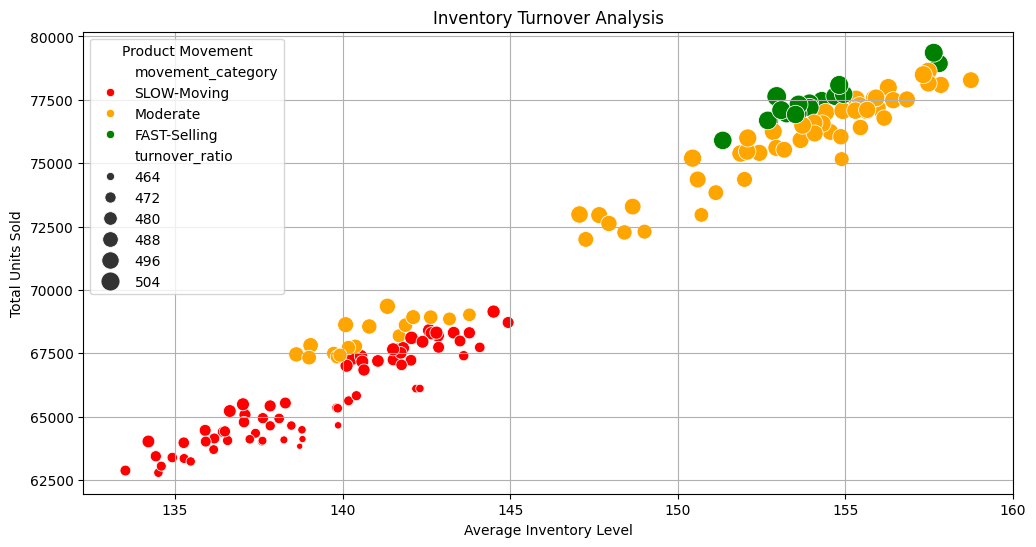

In [20]:
#Inventory Turnover Dashboard
# Calculate turnover ratio 
turnover = dataset.groupby(['Store ID', 'Product ID']).agg(
    total_sales=('Units Sold', 'sum'),
    avg_inventory=('Inventory Level', 'mean')
).reset_index()

turnover['turnover_ratio'] = (turnover['total_sales'] / turnover['avg_inventory']).round(2)
turnover['movement_category'] = pd.cut(
    turnover['turnover_ratio'],
    bins=[0, 480, 500, float('inf')],
    labels=['SLOW-Moving', 'Moderate', 'FAST-Selling']
)

# Create visualization
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=turnover,
    x='avg_inventory',
    y='total_sales',
    hue='movement_category',
    palette={'SLOW-Moving': 'red', 'Moderate': 'orange', 'FAST-Selling': 'green'},
    size='turnover_ratio',
    sizes=(20, 200)
)
plt.title('Inventory Turnover Analysis')
plt.xlabel('Average Inventory Level')
plt.ylabel('Total Units Sold')
plt.legend(title='Product Movement')
plt.grid(True)
plt.show()

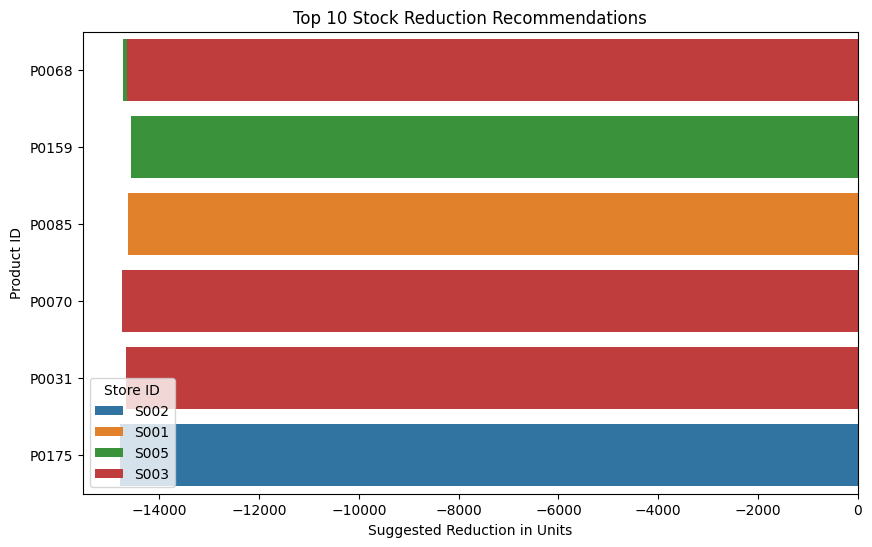

In [23]:
# Calculate suggested reductions
daily_sales = dataset.groupby(['Store ID', 'Product ID'])['Units Sold'].sum().reset_index()
daily_sales['daily_sales'] = (daily_sales['Units Sold'] / 30).round(2)

stock_adjustment = pd.merge(
    dataset.groupby(['Store ID', 'Product ID'])['Inventory Level'].mean().reset_index(),
    daily_sales,
    on=['Store ID', 'Product ID']
)

stock_adjustment['target_stock'] = (stock_adjustment['daily_sales'] * 7).round()
stock_adjustment['suggested_reduction'] = (stock_adjustment['Inventory Level'] - stock_adjustment['target_stock']).round()

# Display top recommendations
top_adjustments = stock_adjustment.sort_values('suggested_reduction', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_adjustments,
    x='suggested_reduction',
    y='Product ID',
    hue='Store ID',
    dodge=False
)
plt.title('Top 10 Stock Reduction Recommendations')
plt.xlabel('Suggested Reduction in Units')
plt.ylabel('Product ID')
plt.show()

Interactive Dashboard

In [33]:
from ipywidgets import interact, Dropdown

# Create interactive store selector
stores = dataset['Store ID'].unique()

@interact(Store=Dropdown(options=stores, description='Select Store:'))
def show_store_kpis(Store):
    store_data = dataset[dataset['Store ID'] == Store]
    
    # Create 3 columns for KPIs
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # KPI 1: Inventory Status
    status_counts = store_data['Inventory Level'].apply(
        lambda x: 'Low' if x < 30 else 'OK'
    ).value_counts()
    ax1.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=['red', 'green'])
    ax1.set_title(f'Inventory Status - {Store}')
    
    # KPI 2: Top Selling Products
    top_products = (store_data.groupby('Product ID', as_index=False)
                   .agg(total_sales=('Units Sold', 'sum'))
                   .nlargest(5, 'total_sales'))
    
    sns.barplot(
        data=top_products,
        x='total_sales', 
        y='Product ID', 
        ax=ax2,
        color='steelblue'
    )
    ax2.set_title('Top Selling Products')
    ax2.set_xlabel('Units Sold')
    
    # KPI 3: Turnover Ratio (Fixed version)
    turnover = (store_data.groupby('Product ID', as_index=False)
                .agg(total_sales=('Units Sold', 'sum'),
                     avg_inventory=('Inventory Level', 'mean')))
    
    turnover['turnover_ratio'] = turnover['total_sales'] / turnover['avg_inventory']
    top_turnover = turnover.nlargest(5, 'turnover_ratio')
    
    sns.barplot(
        data=top_turnover,
        x='turnover_ratio', 
        y='Product ID', 
        ax=ax3,
        color='green'
    )
    ax3.set_title('Top Turnover Ratios')
    ax3.set_xlabel('Turnover Ratio')
    
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Select Store:', options=('S001', 'S002', 'S003', 'S004', 'S005'), …